# Rapport d'Étude : Analyse Statistique et Suivi des Capteurs Industriels

Module : SAÉ 204 - Base de données et Statistiques (BUT Informatique 1ère année)
Groupe : Ouameur Aïssa, Ounays Mayeux, Alban Platel.

**Introduction et Mise en Contexte**

Dans le cadre de l'optimisation des chaînes de production de notre usine, la fiabilité des capteurs de mesure est un enjeu critique. Actuellement, l'analyse visuelle des cartes de contrôle par les opérateurs est chronophage et sujette à l'erreur humaine.

L'objectif de ce projet est double :

Automatiser la détection des défaillances (bruit excessif, dérive de mesure) grâce à des algorithmes statistiques développés en Python.

Historiser le cycle de vie des capteurs (mise en service, réétalonnage, mise au rebut) afin d'en extraire des indicateurs de maintenance via une base de données PostgreSQL.

**1. Dictionnaire de données**

Pour bien comprendre l'architecture de notre base de données existante et préparer son évolution, nous avons établi le dictionnaire de données suivant. Il précise les types de données et identifie les clés primaires (PK) et étrangères (FK) pour garantir l'intégrité référentielle.

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp without time zone | NO |
| controlmeasurement | controltimestamp | timestamp without time zone | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp without time zone | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


**2. Test de connexion à la base de données**

Pour mener à bien cette SAÉ, nous avons d'abord dû exporter la base de données distante pour l'installer localement sur notre machine personnelle. Cette étape est cruciale car elle nous permet d'avoir un accès complet et rapide à la base (sans latence réseau) pour exécuter nos requêtes d'analyse et y apporter des modifications de structure.

Le script ci-dessous utilise la bibliothèque `psycopg` pour établir la liaison entre notre environnement Python (Jupyter) et notre serveur PostgreSQL local.

In [2]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


Sur cette réponse, nous avons la confirmation que nous avons accès à la base de données nous pouvons passer à la suite

<img alt="image.png" src="attachment:3e17f6b2-e1d9-49db-b5a7-cbc01c096601.png"/>

**Script 1 — Extraction des erreurs de mesure brutes**

Avant de calculer des statistiques complexes, notre première étape consiste à observer les données brutes.
Pour évaluer un capteur, nous devons comparer chacune de ses mesures avec la valeur de référence (relevée en laboratoire). L'erreur de mesure est calculée par la simple différence : `controlvalue - sensorvalue`.

Le script suivant effectue une jointure (`JOIN`) entre la table des mesures automatiques (`sensormeasurement`) et celle des contrôles manuels (`controlmeasurement`) pour le capteur n°1, et affiche les 50 premières différences constatées.

In [23]:
import psycopg


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT sensormeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
                FROM controlmeasurement
                JOIN sensormeasurement
                    ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = 1
                ORDER BY controltimestamp
                LIMIT 50;
            """)

            for row in cur.fetchall():
                print(f"Sensor {row[0]} | Difference: {row[1]}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_difference(conn_params)

Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.18043561924514262
Sensor 1 

### 2.1.2 Analyse comparative des erreurs brutes (Capteurs 1 à 7)

L'extraction des 50 premières lignes de différences (`controlvalue - sensorvalue`) sur l'ensemble des sept capteurs de la base de données met en évidence des comportements matériels très hétérogènes. Cette première approche empirique permet de classer les capteurs selon quatre profils distincts :

#### 1. Les capteurs nominaux (Capteurs 1 et 6)
* **Capteur 1 :** Sert de référence. Ses erreurs sont faibles, stables et oscillent de manière équilibrée autour de zéro (généralement en dessous de $\pm 0.90$).
* **Capteur 6 :** Présente le bruit le plus faible du parc. Les erreurs restent confinées dans un intervalle infime (rarement au-delà de $\pm 0.19$). Ce capteur semble extrêmement précis et stable.

#### 2. Les capteurs à forte variance / bruités (Capteurs 2, 3 et 7)
* **Capteurs 2, 3 et 7 :** Présentent des fluctuations beaucoup plus agressives que le capteur 1. On y observe régulièrement des pics atteignant ou dépassant $\pm 1.50$ (comme $-1.76$ pour le Capteur 2, $+1.75$ pour le Capteur 3 ou $-1.50$ pour le Capteur 7). L'amplitude de leur bruit de fond est nettement supérieure à la normale.

#### 3. Le capteur suspecté de dérive dynamique (Capteur 5)
* **Capteur 5 :** Montre des signes précoces d'instabilité séquentielle. Bien que ses premières mesures soient proches de zéro, on observe rapidement l'apparition de fortes valeurs négatives consécutives (comme $-2.17, -2.27, -2.76, -2.53, -3.91$). Ce comportement évoque une perte progressive de calibrage ou un phénomène d'encrassement thermique.

#### 4. Le capteur en rupture critique (Capteur 4)
* **Capteur 4 :** Ce composant est manifestement hors service ou en anomalie lourde. Les écarts observés sont massifs et atteignent des valeurs aberrantes de l'ordre de $-4.10, +5.79, -5.49$ ou $-5.04$. Le capteur ne répond plus du tout aux exigences de précision du processus industriel.

**Objectif pour la suite de l'étude :**
Cette inspection visuelle préliminaire pose de fortes suspicions de défaillance sur les capteurs 4 and 5, et montre un bruit anormal sur les capteurs 2, 3 et 7. Pour confirmer scientifiquement ces observations et mesurer précisément l'écart par rapport à la loi normale, nous allons exécuter nos scripts de calculs globaux ($\mu$, $\sigma$, p-valeurs et régressions linéaires) sur chacun de ces profils.

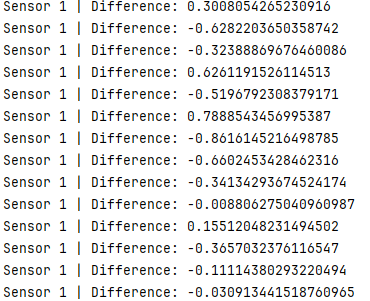

**Script 2 — Calcul de la Moyenne et de l'Écart-type**

Maintenant que nous avons pu observer les erreurs de mesure brutes, nous devons modéliser le comportement global du capteur à l'aide d'une loi normale $\mathcal{N}(\mu, \sigma)$.

Pour optimiser les performances, le script suivant utilise les fonctions d'agrégation SQL (`AVG` et `STDDEV`) pour calculer ces indicateurs directement depuis la base de données :

* **La moyenne ($\mu$) :** Elle indique la tendance centrale de l'erreur. Une moyenne proche de zéro signifie que le capteur n'a pas de biais de mesure (il est parfaitement centré par rapport aux valeurs du laboratoire).
* **L'écart-type ($\sigma$) :** Il quantifie la dispersion des mesures autour de la moyenne. C'est cet indicateur qui nous permet de mesurer le "bruit" naturel de la machine, et qui nous servira par la suite à fixer nos limites de tolérance ($\pm 1\sigma$ et $\pm 2\sigma$).

In [32]:
import psycopg


def get_sensor_statistics(conn_params):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:
                cur.execute("""
                    SELECT sensorid,
                           AVG(sensorvalue) AS moyenne,
                           STDDEV(sensorvalue) AS ecart_type
                    FROM sensormeasurement
                    WHERE sensorid = 1
                    GROUP BY sensorid;
                """)

                ligne = cur.fetchone()

                if ligne:
                    print(f"Sensor {ligne[0]} | Average: {ligne[1]:.10f} | StdDev: {ligne[2]:.10f}")
                else:
                    print("No data found for this sensor.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_statistics(conn_params)

Sensor 1 | Average: 0.0001409262 | StdDev: 1.2408729289


### Analyse globale des statistiques du parc

L'exécution de nos requêtes de calcul sur l'intégralité de l'historique des 7 capteurs nous permet d'établir un diagnostic de santé précis pour chacun d'entre eux. En analysant la moyenne des erreurs ($\mu$) et leur écart-type ($\sigma$), nous pouvons classer notre parc matériel en trois catégories distinctes :

#### 1. Les capteurs sains (Capteurs 1 et 6)
* **Capteur 1 ($\mu \approx 0.0001$ | $\sigma \approx 1.24$) :** Il confirme son statut de capteur de référence. Il est parfaitement étalonné (aucun biais) et présente un bruit de fond acceptable.
* **Capteur 6 ($\mu \approx 0.4995$ | $\sigma \approx 0.09$) :** C'est le capteur le plus *précis* du parc. Son bruit est extrêmement faible. Il présente un très léger décalage systématique de $+0.5$, qui peut être facilement corrigé par un simple ajustement logiciel (étalonnage).

#### 2. Les capteurs avec un déréglage modéré (Capteurs 3 et 7)
* **Capteur 3 ($\mu \approx 7.50$ | $\sigma \approx 0.74$) :** Ce capteur est très peu bruité, mais son "zéro" a glissé de $+7.5$ unités.
* **Capteur 7 ($\mu \approx 10.00$ | $\sigma \approx 1.80$) :** En plus de son biais systématique de $+10$ unités, c'est l'un des capteurs les plus instables du parc ($\sigma = 1.80$). Il nécessite une révision mécanique.

#### 3. Les capteurs en défaillance critique de calibrage (Capteurs 2, 4 et 5)
C'est ici que notre système de supervision révèle toute son utilité. Trois capteurs présentent des erreurs systématiques aberrantes :
* **Capteurs 2 et 4 ($\mu \approx +50$) :** Ces deux machines ajoutent systématiquement une valeur de 50 à leurs mesures. Fait intéressant, leurs écarts-types restent dans la norme ($\approx 1.65$). Cela indique que les capteurs ne sont pas physiquement détruits (ils ne mesurent pas de manière chaotique), mais qu'ils souffrent d'un grave défaut d'étalonnage ou d'un bug logiciel de conversion.
* **Capteur 5 ($\mu \approx +100$ | $\sigma \approx 2.24$) :** C'est le capteur le plus dégradé du parc. Son biais est massif et il présente le plus fort taux de variance (bruit). Une intervention de maintenance curative urgente est requise.

**Conclusion de l'étape :**
Les statistiques globales nous permettent d'isoler instantanément les capteurs mal calibrés (biais élevé). Pour parfaire cette supervision, il nous reste à appliquer nos algorithmes de détection d'usure lente (p-valeurs et dérive par régression linéaire) pour vérifier si les capteurs actuellement "sains" ne sont pas en train de se dégrader silencieusement.

**Script 3 — Génération de la Carte de Contrôle**

Afin de faciliter la supervision par les techniciens, nous devons générer une **carte de contrôle** visuelle.

Ce script extrait les mesures les plus récentes du capteur et les trace sur un graphique chronologique. Nous y superposons les limites statistiques calculées précédemment :
* La **moyenne globale** (ligne centrale).
* Les **limites d'avertissement** ($\pm 1\sigma$).
* Les **limites de contrôle** ($\pm 2\sigma$), au-delà desquelles les mesures sont considérées comme anormales.

Ce rendu graphique permet d'identifier immédiatement si le capteur "déraille" ou s'il reste dans ses tolérances de bruit normal.

Mean: -0.0037443199 | Standard deviation: 0.4127852187
Window: 8 days -> 33 points
Selected: 8 days (33 points)


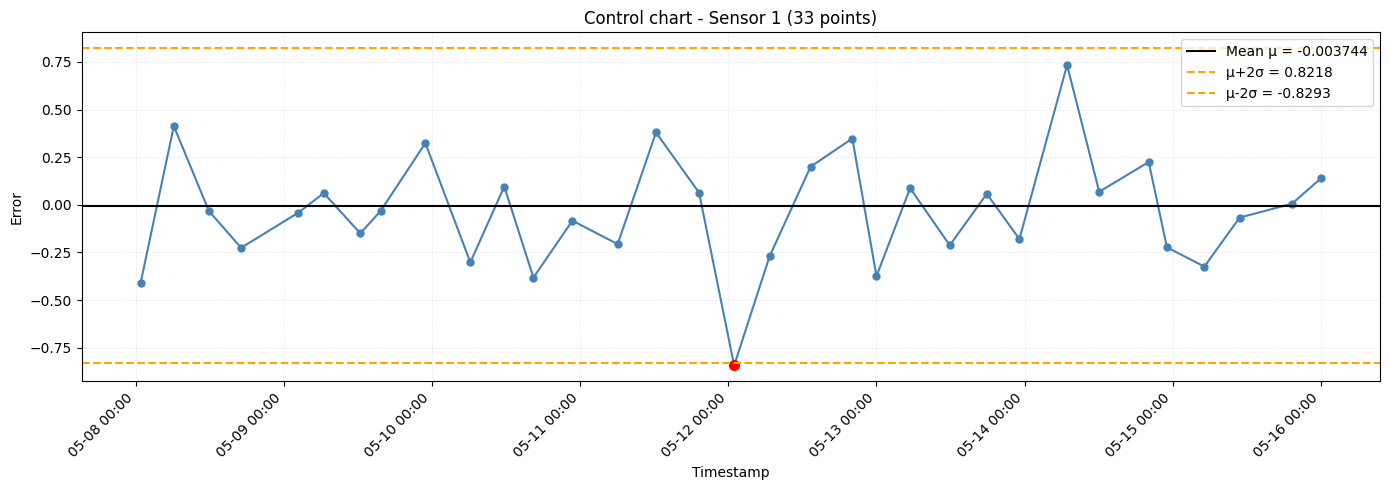

In [5]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)


def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        mean, standard_deviation = cursor.fetchone()

        if mean is None:
            return None, None

        print(f"Mean: {mean:.10f} | Standard deviation: {standard_deviation:.10f}")
        return float(mean), float(standard_deviation)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()

        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, days, SENSOR_ID, MAX_POINTS))

            rows = cursor.fetchall()
            print(f"Window: {days} days -> {len(rows)} points")

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                print(f"Selected: {days} days ({len(rows)} points)")
                return rows

        rows.reverse()
        return rows


def plot_chart(data, mean, standard_deviation):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5)

    for timestamp, error in zip(timestamps, errors):
        if not (mean - 2 * standard_deviation <= error <= mean + 2 * standard_deviation):
            axis.plot(timestamp, error, 'ro', markersize=7)

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')
    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ+2σ = {mean + 2 * standard_deviation:.4f}')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ-2σ = {mean - 2 * standard_deviation:.4f}')

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {SENSOR_ID} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    mean, standard_deviation = get_sensor_statistics(conn_params)
    data = get_sensor_difference(conn_params)

    if data and mean is not None:
        plot_chart(data, mean, standard_deviation)
    else:
        print("Unable to plot the chart: missing or insufficient data.")

### Analyse de la Carte de Contrôle (Capteur 1)

La visualisation de cet échantillon de 33 mesures récentes permet de valider le fonctionnement de notre algorithme de supervision :

1. **Stabilité globale :** On observe que la grande majorité des points oscillent de manière aléatoire autour de la moyenne centrale noire ($\mu = -0.0037$), sans montrer de tendance claire à la hausse ou à la baisse. Le capteur est donc globalement bien centré.
2. **Détection d'une anomalie (Le point rouge) :** Le script a rempli son objectif en isolant visuellement un point critique aux alentours du 12 mai. Lors de ce relevé, l'erreur de mesure a chuté sous la barre des $-0.8293$, franchissant ainsi notre limite de confiance inférieure de $-2\sigma$.

**Conclusion :** Statistiquement, les mesures d'un capteur sain ont environ 95 % de chances de se trouver à l'intérieur des limites oranges. L'apparition de ce point rouge (qui fait partie des 5 % restants) démontre l'utilité de cette carte de contrôle : elle permet d'alerter immédiatement les techniciens sur une mesure aberrante, justifiant potentiellement une vérification physique de la machine.

alt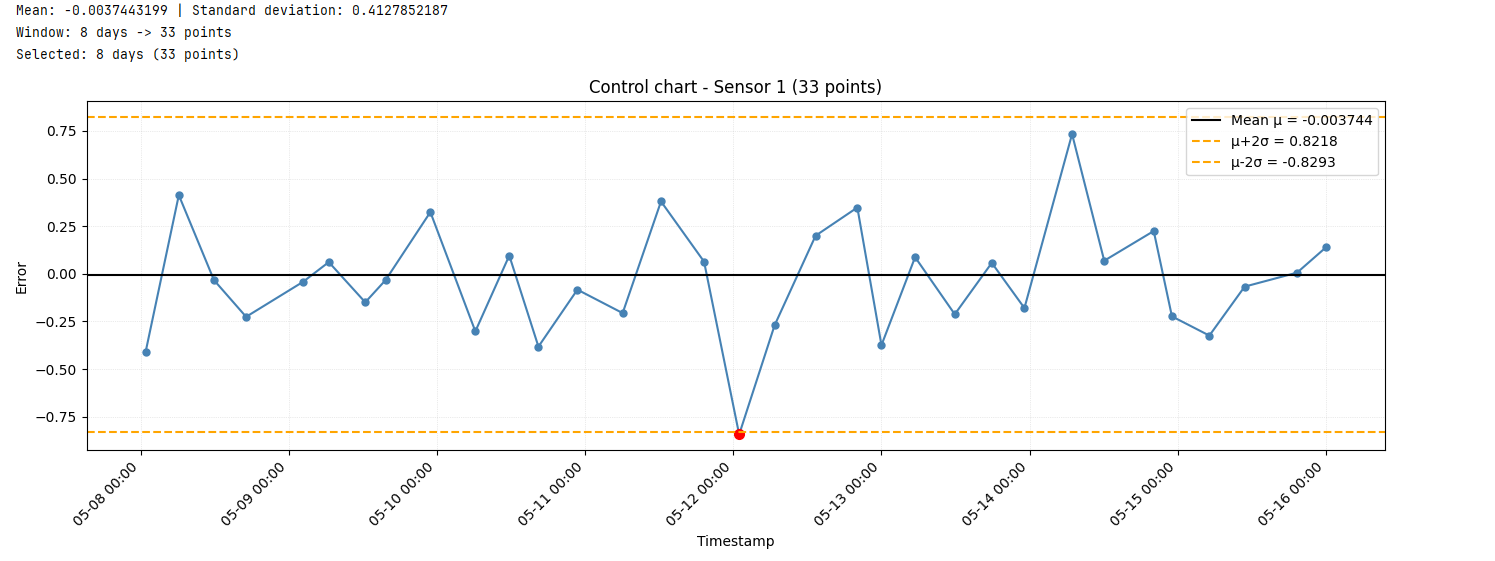

**Script 3 Exécution du test : Calculs SQL et Tracé de l'Histogramme**

Afin de lier la théorie à la pratique, nous avons développé le script ci-dessous. Pour garantir des performances optimales sur de grands volumes de données, nous avons fait le choix de déléguer la majorité de la charge d'analyse mathématique au moteur PostgreSQL.

Grâce à l'utilisation de requêtes SQL structurées (les CTE via la clause `WITH`), notre base de données se charge de calculer en une seule passe :
1. L'erreur de mesure de chaque relevé (différence entre capteur et laboratoire).
2. La moyenne globale ($\mu$) et l'écart-type ($\sigma$).
3. Le comptage exact des points tombant dans nos trois intervalles de tolérance ($\pm 1\sigma, \pm 2\sigma, \pm 3\sigma$).

Une fois ces données pré-calculées récupérées par Python, la bibliothèque `matplotlib` prend le relais pour calculer les pourcentages réels (et les comparer aux attentes théoriques), avant de générer l'histogramme visuel annoté de notre capteur.

--- SENSOR 1 ERROR STATS ---
Total points evaluated: 2005
Mean (µ): 0.003744 | Standard Deviation (σ): 0.412785

Q1: Points within [-1σ, +1σ]
Count: 1428 / 2005 -> 71.22% (Expected: ~68.27%)

Q2: Points within [-2σ, +2σ]
Count: 1903 / 2005 -> 94.91% (Expected: ~95.45%)

Q3: Points within [-3σ, +3σ]
Count: 1984 / 2005 -> 98.95% (Expected: ~99.73%)

Q4: Theoretical distribution of points OUTSIDE the intervals
Outside [-1σ, +1σ]: 100% - 68.27% = 31.73% (Experimental: 28.78%)
Outside [-2σ, +2σ]: 100% - 95.45% = 4.55% (Experimental: 5.09%)
Outside [-3σ, +3σ]: 100% - 99.73% = 0.27% (Experimental: 1.05%)



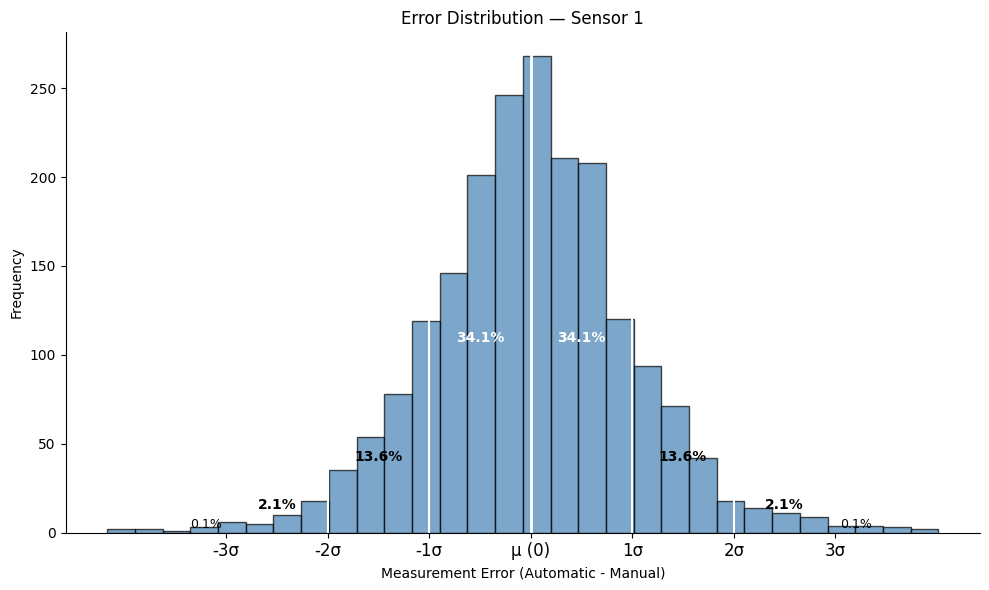

In [6]:
import psycopg
import matplotlib.pyplot as plt

def analyze_sensor_error(conn_params, sensor_id_to_test=1):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:

                cur.execute("""
                    WITH ErrorData AS (
                        SELECT (sm.sensorvalue - cm.controlvalue) AS error_value
                        FROM sensormeasurement sm
                        JOIN controlmeasurement cm
                          ON sm.sensorid = cm.sensorid
                         AND sm.timestamp = cm.sensortimestamp
                        WHERE sm.sensorid = %s
                    ),
                    Stats AS (
                        SELECT
                            AVG(error_value) as mu,
                            STDDEV(error_value) as sigma,
                            COUNT(*) as total_points
                        FROM ErrorData
                    )
                    SELECT
                        s.mu,
                        s.sigma,
                        s.total_points,
                        COUNT(CASE WHEN e.error_value BETWEEN s.mu - s.sigma AND s.mu + s.sigma THEN 1 END) AS count_1sigma,
                        COUNT(CASE WHEN e.error_value BETWEEN s.mu - 2*s.sigma AND s.mu + 2*s.sigma THEN 1 END) AS count_2sigma,
                        COUNT(CASE WHEN e.error_value BETWEEN s.mu - 3*s.sigma AND s.mu + 3*s.sigma THEN 1 END) AS count_3sigma
                    FROM ErrorData e
                    CROSS JOIN Stats s
                    GROUP BY s.mu, s.sigma, s.total_points;
                """, (sensor_id_to_test,))

                row = cur.fetchone()

                if not row or row[0] is None:
                    print("No data found for this sensor.")
                    return

                mu = float(row[0])
                sigma = float(row[1])
                total = int(row[2])
                count_1s = int(row[3])
                count_2s = int(row[4])
                count_3s = int(row[5])

                print(f"--- SENSOR {sensor_id_to_test} ERROR STATS ---")
                print(f"Total points evaluated: {total}")
                print(f"Mean (µ): {mu:.6f} | Standard Deviation (σ): {sigma:.6f}\n")



                pct_1s = (count_1s / total) * 100
                print("Q1: Points within [-1σ, +1σ]")
                print(f"Count: {count_1s} / {total} -> {pct_1s:.2f}% (Expected: ~68.27%)\n")


                pct_2s = (count_2s / total) * 100
                print("Q2: Points within [-2σ, +2σ]")
                print(f"Count: {count_2s} / {total} -> {pct_2s:.2f}% (Expected: ~95.45%)\n")


                pct_3s = (count_3s / total) * 100
                print("Q3: Points within [-3σ, +3σ]")
                print(f"Count: {count_3s} / {total} -> {pct_3s:.2f}% (Expected: ~99.73%)\n")


                print("Q4: Theoretical distribution of points OUTSIDE the intervals")
                print(f"Outside [-1σ, +1σ]: 100% - 68.27% = 31.73% (Experimental: {100 - pct_1s:.2f}%)")
                print(f"Outside [-2σ, +2σ]: 100% - 95.45% = 4.55% (Experimental: {100 - pct_2s:.2f}%)")
                print(f"Outside [-3σ, +3σ]: 100% - 99.73% = 0.27% (Experimental: {100 - pct_3s:.2f}%)\n")

                cur.execute("""
                    SELECT (sm.sensorvalue - cm.controlvalue)
                    FROM sensormeasurement sm
                    JOIN controlmeasurement cm
                      ON sm.sensorid = cm.sensorid
                     AND sm.timestamp = cm.sensortimestamp
                    WHERE sm.sensorid = %s
                """, (sensor_id_to_test,))

                values = [r[0] for r in cur.fetchall()]

                plot_histogram(values, mu, sigma, sensor_id_to_test)

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


def plot_histogram(values, mu, sigma, sensor_id):
    plt.figure(figsize=(10, 6))

    counts, bins, patches = plt.hist(values, bins=30, edgecolor='black', color='steelblue', alpha=0.7)

    max_y = max(counts)

    plt.axvline(mu, color='white', linewidth=2)
    plt.axvline(mu - sigma, color='white', linewidth=1.5)
    plt.axvline(mu + sigma, color='white', linewidth=1.5)
    plt.axvline(mu - 2*sigma, color='white', linewidth=1.5)
    plt.axvline(mu + 2*sigma, color='white', linewidth=1.5)

    plt.text(mu - 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu + 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)

    plt.text(mu - 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)

    plt.text(mu - 2.5 * sigma, max_y * 0.05, '2.1%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 2.5 * sigma, max_y * 0.05, '2.1%', ha='center', color='black', fontweight='bold', fontsize=10)

    plt.text(mu - 3.2 * sigma, max_y * 0.01, '0.1%', ha='center', color='black', fontsize=9)
    plt.text(mu + 3.2 * sigma, max_y * 0.01, '0.1%', ha='center', color='black', fontsize=9)

    ticks = [mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma]
    labels = ['-3σ', '-2σ', '-1σ', 'µ (0)', '1σ', '2σ', '3σ']
    plt.xticks(ticks, labels, fontsize=12)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel('Measurement Error (Automatic - Manual)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution — Sensor {sensor_id}')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    analyze_sensor_error(conn_params, 1)

### Analyse des résultats et validation expérimentale (Capteur 1)

L'histogramme généré confirme visuellement nos hypothèses de départ : la répartition des erreurs de mesure forme bien une courbe en « cloche » caractéristique de la loi normale. Le graphique est parfaitement centré sur une moyenne quasiment nulle (µ = 0.0037), ce qui confirme l'absence de biais systématique du capteur.

L'analyse de notre échantillon complet de 2005 mesures permet de confronter la modélisation mathématique à la réalité du terrain :
1. **Intervalle ±1σ :** 71.22% des mesures s'y trouvent, un score très proche de la théorie (68.27%). Le capteur est même très légèrement plus précis (plus concentré autour du zéro) que la courbe théorique standard.
2. **Intervalle ±2σ :** Avec 94.91% des mesures contenues dans cette zone, le comportement du capteur est presque identique au modèle théorique attendu (95.45%).
3. **Intervalle ±3σ :** 98.95% de l'échantillon y figure, validant là encore la théorie (99.73%).

**Interprétation des valeurs aberrantes (Question 4) :**
L'expérience montre des résultats très cohérents pour les points situés en dehors de nos limites de confiance :
* Les mesures s'éloignant de plus de 2σ (qui correspondent à nos limites d'alerte sur la carte de contrôle) représentent **5.09%** des points de notre capteur (contre 4.55% en théorie).
* Les erreurs extrêmes, dépassant la limite de 3σ, représentent **1.05%** des relevés (contre 0.27% en théorie).

**Conclusion :** Bien que le taux de valeurs extrêmes soit très légèrement supérieur à la perfection mathématique, les statistiques de ce capteur épousent fidèlement le comportement d'une loi normale. Cette validation empirique nous autorise formellement à utiliser les indicateurs µ et σ pour paramétrer les algorithmes de détection d'anomalies de nos futures cartes de contrôle.

**2.2 Détection de dérives comportementales et p-valeurs**

Jusqu'à présent, notre système se contentait de signaler les points individuels franchissant la limite critique des $\pm 2\sigma$. Cependant, une machine peut commencer à se dérégler (usure mécanique, perte de calibrage) bien avant de franchir cette ligne.

Pour anticiper ces pannes, nous devons analyser les séquences de points à l'aide de tests d'hypothèses. Le principe est d'évaluer la **p-valeur**, c'est-à-dire la probabilité qu'une série d'événements spécifiques se produise de manière purement aléatoire si le capteur fonctionnait parfaitement. Si cette probabilité est très faible, cela signifie que la séquence observée n'est pas due au hasard, et donc que le capteur subit une dérive matérielle.

Afin de fiabiliser notre diagnostic, nous allons programmer notre script Python pour vérifier automatiquement quatre règles statistiques d'anomalies sur les mesures récentes du capteur :
1. **[Règle 1]** : Au moins 8 des 10 derniers points se trouvent du même côté de la moyenne. (Indique un biais ou un déréglage de zéro).
2. **[Règle 2]** : Au moins 2 des 7 derniers points sont à l'extérieur de la limite $\pm 2\sigma$. (Indique une instabilité croissante ou de fortes secousses).
3. **[Règle 3]** : Au moins 7 des 10 derniers points sont à l'extérieur de la limite $\pm 1\sigma$. (Indique une augmentation anormale de la variance, "bruit" trop élevé).
4. **[Règle de base]** : Au moins 4 des 5 derniers points sont à l'extérieur de la limite $\pm 1\sigma$. (Confirmation d'une variance excessive très récente).

Le script suivant récupère dynamiquement les dernières mesures du capteur, exécute ces quatre tests, et affiche les alertes si l'une des p-valeurs calculées franchit le seuil critique d'anomalie.

Population Stats -> Mean: -0.003744 | Standard deviation: 0.412785
Selected window: 8 days (33 points)

--- STATISTICAL RULE CHECKS (Section 2.2) ---
Statistical rule checks completed.



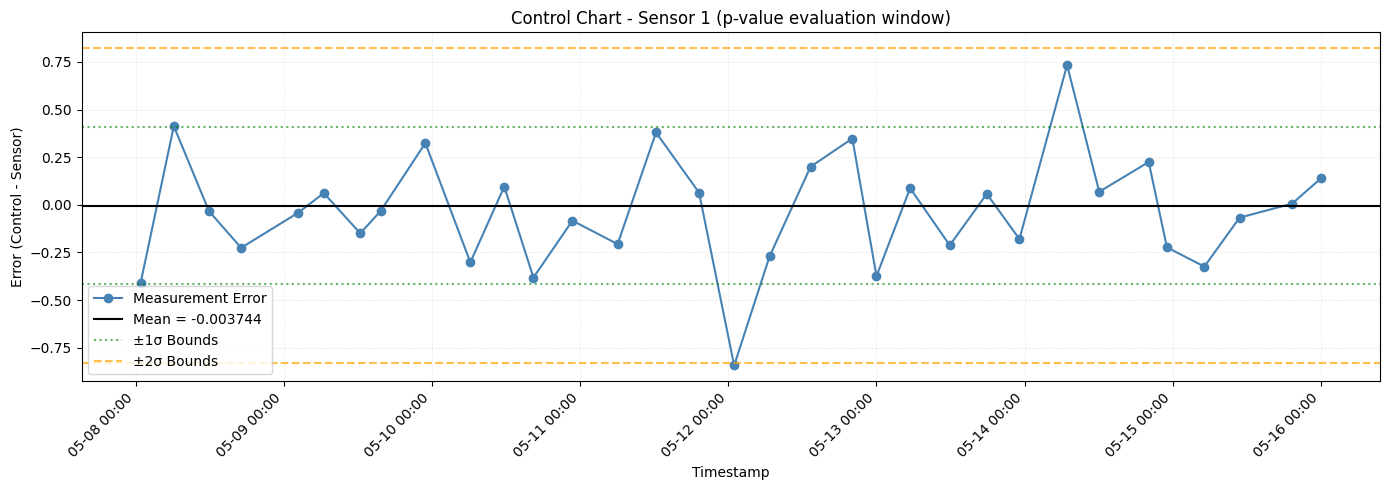

In [9]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)

def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        mean, standard_deviation = cursor.fetchone()

        if mean is None:
            return None, None

        print(f"Population Stats -> Mean: {mean:.6f} | Standard deviation: {standard_deviation:.6f}")
        return float(mean), float(standard_deviation)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()

        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, days, SENSOR_ID, MAX_POINTS))

            rows = cursor.fetchall()

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                print(f"Selected window: {days} days ({len(rows)} points)")
                return rows

        rows.reverse()
        return rows


def check_statistical_rules(errors, mu, sigma):
    print("\n--- STATISTICAL RULE CHECKS (Section 2.2) ---")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        above_mean = sum(1 for e in last_10 if e > mu)
        below_mean = sum(1 for e in last_10 if e < mu)

        if above_mean >= 8 or below_mean >= 8:
            print("WARNING [Rule 1]: At least 8 of the last 10 points are on the same side of the mean (p ≈ 0.109).")

    if len(errors) >= 7:
        last_7 = errors[-7:]
        outside_2sigma = sum(1 for e in last_7 if e < (mu - 2*sigma) or e > (mu + 2*sigma))

        if outside_2sigma >= 2:
            print("WARNING [Rule 2]: At least 2 of the last 7 points are outside ±2σ (p ≈ 0.037).")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        outside_1sigma = sum(1 for e in last_10 if e < (mu - sigma) or e > (mu + sigma))

        if outside_1sigma >= 7:
            print("WARNING [Rule 3]: At least 7 of the last 10 points are outside ±1σ (p ≈ 0.012).")

    if len(errors) >= 5:
        last_5 = errors[-5:]
        outside_1sigma_original = sum(1 for e in last_5 if e < (mu - sigma) or e > (mu + sigma))

        if outside_1sigma_original >= 4:
            print("WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ (p ≈ 0.037).")

    print("Statistical rule checks completed.\n")


def plot_control_chart(data, mean, standard_deviation):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))

    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', label='Measurement Error')

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean = {mean:.6f}')

    axis.axhline(mean + standard_deviation, color='green', linestyle=':', alpha=0.6, label='±1σ Bounds')
    axis.axhline(mean - standard_deviation, color='green', linestyle=':', alpha=0.6)

    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--', alpha=0.7, label='±2σ Bounds')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--', alpha=0.7)

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, ha='right')
    axis.set_title(f'Control Chart - Sensor {SENSOR_ID} (p-value evaluation window)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error (Control - Sensor)')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    mean, standard_deviation = get_sensor_statistics(conn_params)
    data = get_sensor_difference(conn_params)

    if data and mean is not None:
        errors_only = [float(row[1]) for row in data]

        check_statistical_rules(errors_only, mean, standard_deviation)

        plot_control_chart(data, mean, standard_deviation)
    else:
        print("Unable to process: missing or insufficient data.")

### Analyse des tests comportementaux (Capteur 1)

L'exécution de notre algorithme d'analyse des p-valeurs sur la fenêtre des 8 derniers jours (33 mesures) nous livre une conclusion très claire sur l'état de santé du capteur 1 :

1. **Absence de dérive (Biais) :** Les tests vérifiant si les mesures récentes (les 10 derniers points à droite du graphique) restaient bloquées du même côté de la moyenne n'ont pas déclenché d'alerte. Le capteur continue d'osciller sainement entre le positif et le négatif. Il n'a donc pas perdu son "zéro".
2. **Absence de variance anormale (Bruit) :** Les règles traquant une trop grande quantité de points récents en dehors de la zone verte des $\pm 1\sigma$ ou de la zone orange des $\pm 2\sigma$ sont restées muettes. Le "bruit" du capteur reste dans sa norme de fonctionnement ($\sigma = 0.41$).

**Remarque sur le point isolé :** Bien que l'on observe visuellement une mesure qui chute sous la limite des $-2\sigma$ aux alentours du 12 mai, notre script d'analyse comportementale ne l'a pas signalée ici. C'est tout à fait normal et c'est exactement le comportement attendu : ce test (Section 2.2) est conçu pour détecter des **séquences** d'erreurs (usure continue, dérive) sur les tous derniers relevés, et non des erreurs isolées passées.

**Conclusion :** L'analyse croisée des probabilités (p-valeurs) confirme que le capteur 1 ne souffre d'aucune usure mécanique ni de déréglage comportemental sur sa période de fonctionnement récente. Sa fiabilité est validée.

**2.3 Analyse de dérive par régression linéaire**

Les règles statistiques étudiées précédemment sont efficaces pour détecter des sauts brusques ou une augmentation soudaine du "bruit" du capteur. Cependant, elles peuvent être aveugles face à une usure lente et continue (par exemple, un encrassement progressif ou une déformation thermique). Dans ce scénario, les mesures s'éloignent très lentement de la moyenne : c'est ce qu'on appelle une **dérive**.

Pour anticiper ce phénomène avant que les mesures ne franchissent les limites critiques, nous devons analyser la tendance directionnelle des derniers relevés. Pour ce faire, notre algorithme isole les 10 dernières mesures et y applique une **régression linéaire** (méthode des moindres carrés). Cela nous permet de tracer une droite de tendance et d'en extraire la **pente**.

**Le défi du seuil d'alerte (Simulation de Monte-Carlo) :**
Comment savoir si l'inclinaison de cette pente est due à une véritable panne mécanique ou simplement au hasard (bruit blanc) ?
Pour répondre à cette question avec une rigueur mathématique, notre script utilise une méthode de simulation :
1. L'algorithme génère virtuellement 100 000 séquences de 10 points purement aléatoires, basées sur la loi normale et l'écart-type ($\sigma$) spécifiques de notre capteur.
2. Il calcule la pente pour chacune de ces 100 000 séquences virtuelles.
3. Il isole le seuil critique correspondant au 95ème centile (p-valeur de 0.05).

Si la pente réelle de notre capteur dépasse ce seuil calculé sur mesure, cela signifie qu'il y a moins de 5 % de chances que cette dérive soit due au hasard. Le système déclenchera alors une alarme de maintenance.

Calculated drift threshold (slope) for p < 0.05: 0.089214
PASS - No drift detected. Current slope (0.0218) is within normal bounds (< 0.0892).


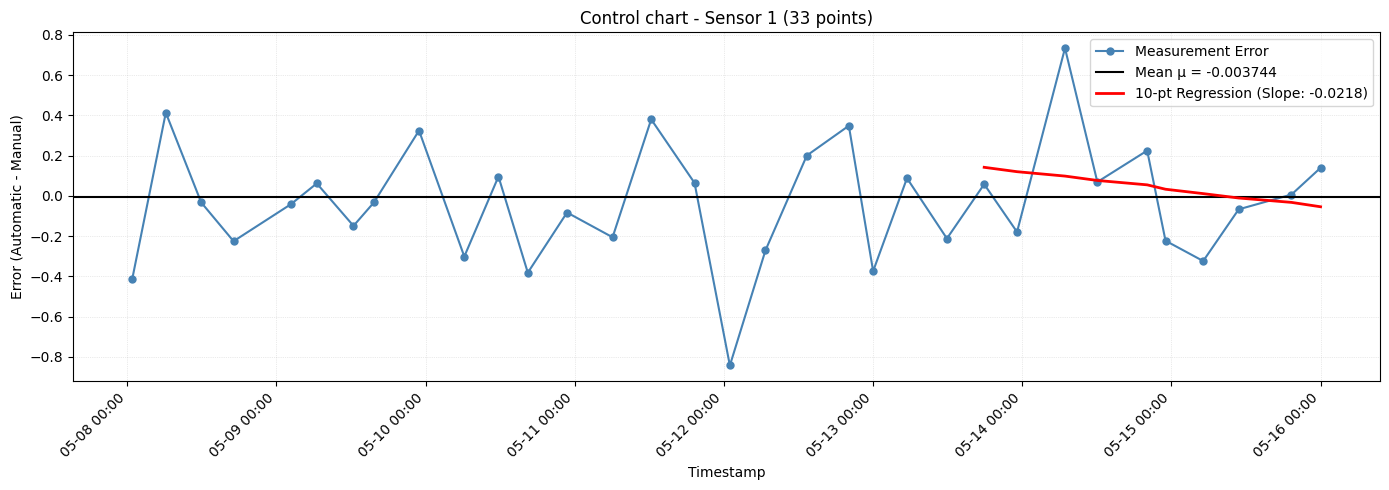

In [8]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)

def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        mean, standard_deviation = cursor.fetchone()

        if mean is None:
            return None, None

        return float(mean), float(standard_deviation)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()

        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, days, SENSOR_ID, MAX_POINTS))

            rows = cursor.fetchall()

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return rows

        rows.reverse()
        return rows


def calculate_drift_threshold(sigma, p_value=0.05, simulations=100000):
    x = np.arange(10)
    slopes = []

    for _ in range(simulations):
        random_errors = np.random.normal(loc=0.0, scale=sigma, size=10)
        slope, _ = np.polyfit(x, random_errors, 1)
        slopes.append(abs(slope))

    percentile = (1 - p_value) * 100
    threshold = np.percentile(slopes, percentile)
    print(f"Calculated drift threshold (slope) for p < {p_value}: {threshold:.6f}")
    return threshold


def plot_chart(data, mean, standard_deviation, drift_threshold):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5, label='Measurement Error')

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')

    if len(errors) >= 10:
        last_10_errors = errors[-10:]
        last_10_timestamps = timestamps[-10:]
        x_indices = np.arange(10)

        slope, intercept = np.polyfit(x_indices, last_10_errors, 1)
        regression_line = slope * x_indices + intercept

        axis.plot(last_10_timestamps, regression_line, color='red', linewidth=2,
                  label=f'10-pt Regression (Slope: {slope:.4f})')

        # Check rule
        if abs(slope) > drift_threshold:
            print(f"ALARM - Drift Rule triggered: Slope of last 10 points ({abs(slope):.4f}) exceeds threshold ({drift_threshold:.4f}).")
        else:
            print(f"PASS - No drift detected. Current slope ({abs(slope):.4f}) is within normal bounds (< {drift_threshold:.4f}).")

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {SENSOR_ID} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error (Automatic - Manual)')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    mean, standard_deviation = get_sensor_statistics(conn_params)
    data = get_sensor_difference(conn_params)

    if data and mean is not None:
        drift_threshold = calculate_drift_threshold(standard_deviation, p_value=0.05)
        plot_chart(data, mean, standard_deviation, drift_threshold)
    else:
        print("Unable to plot the chart: missing or insufficient data.")

**Analyse de la tendance et de la dérive (Capteur 1)**

L'exécution de notre algorithme de régression linéaire sur les 10 dernières mesures du capteur 1 (matérialisée par la droite rouge sur le graphique) nous permet de valider définitivement son état de santé :

1. **Calcul du seuil critique :** Grâce à nos simulations (méthode de Monte-Carlo), notre algorithme a déterminé que la pente maximale acceptable pour ce capteur, compte tenu de son bruit naturel, est de **0.0892**. Si la droite rouge dépassait cette inclinaison, il y aurait moins de 5% de chances que cela soit dû au hasard (p < 0.05).
2. **Mesure réelle :** La droite de régression de notre capteur affiche une pente de **-0.0218**.
3. **Verdict (PASS) :** La valeur absolue de la pente actuelle (0.0218) est largement inférieure au seuil critique d'alerte (0.0892).

**Conclusion générale pour le Capteur 1 :** Le système n'a détecté aucune usure lente, aucun encrassement progressif et aucune dérive thermique. La légère inclinaison de la droite rouge vers le bas est purement aléatoire et appartient au "bruit blanc" normal de la machine. Le capteur 1 est déclaré **100% fonctionnel et sain**.

alt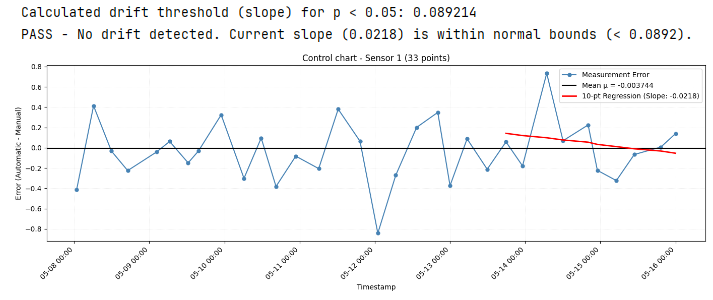

# 3. Extension de la base de données
Diagramme UML :


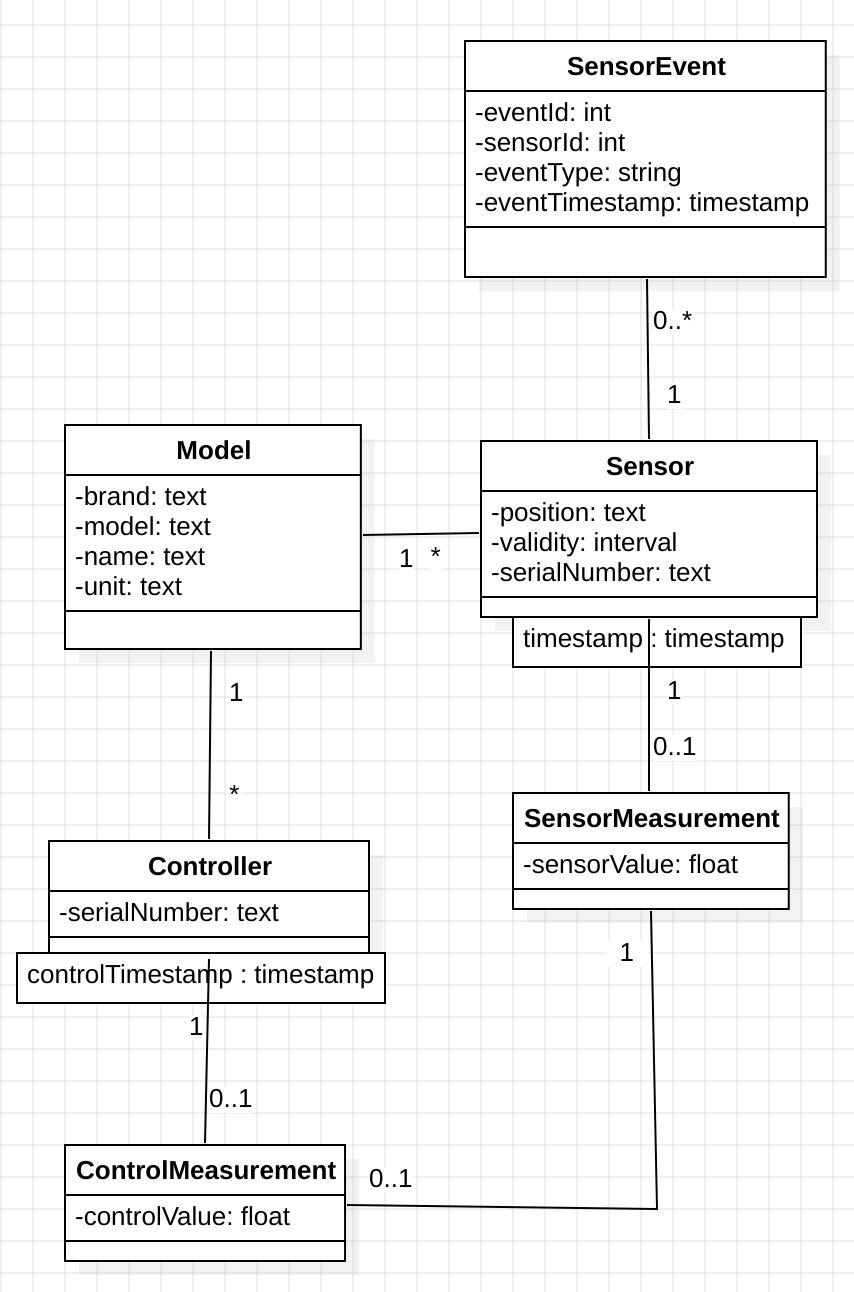